In [72]:
%pip install pandas pyarrow fastparquet duckdb seaborn matplotlib ydata_profiling

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
import pandas as pd
import glob
from datetime import datetime

fecha_actual = datetime.now().strftime("%Y-%m-%d-%H%M%S")

# 1. Definir el patrón de búsqueda de los archivos
patron = '../dataset/at_urg_respiratorio_*.parquet'

# 2. Buscar todos los archivos que coincidan con el patrón
archivos_encontrados = glob.glob(patron)

# 3. Verificar si hay archivos y seleccionar el más reciente
if archivos_encontrados:
    # Como el formato es YYYY-MM-DD, max() devolverá el archivo con la fecha más reciente
    archivo_mas_reciente = max(archivos_encontrados)
    
    print(f"Cargando el archivo más reciente: {archivo_mas_reciente}")
    
    # 4. Leer el archivo
    df = pd.read_parquet(archivo_mas_reciente, engine='fastparquet')
    
    # Mostrar resultados
    from IPython.display import display
    display(df.head())
    print("\nTipos de datos:\n", df.dtypes)
    
else:
    print("No se encontraron archivos en la ruta especificada.")

Cargando el archivo más reciente: ../dataset\at_urg_respiratorio_2026-06-16.parquet


,EstablecimientoCodigo,EstablecimientoGlosa,RegionCodigo,RegionGlosa,ComunaCodigo,ComunaGlosa,ServicioSaludCodigo,ServicioSaludGlosa,TipoEstablecimiento,DependenciaAdministrativa,...,Anio,SemanaEstadistica,OrdenCausa,Causa,NumTotal,NumMenor1Anio,Num1a4Anios,Num5a14Anios,Num15a64Anios,Num65oMas
0,200144,SAPU José Alvo,13,Región Metropolitana de Santiago,13110,La Florida,14,Servicio de Salud Metropolitano Sur Oriente,Servicio de Atención Primaria de Urgencia (SAPU),Municipal,...,2016,2,9,Otra causa respiratoria no contenidas en las c...,3,0,2,0,1,0
1,102807,SAPU El Boro,1,Región De Tarapacá,1107,Alto Hospicio,2,Servicio de Salud Tarapacá,Servicio de Atención Primaria de Urgencia (SAPU),Municipal,...,2014,36,4,IRA Alta (J00-J06),93,8,20,27,36,2
2,200177,SAPU 2 Septiembre,8,Región Del Bíobío,8301,Los Ángeles,20,Servicio de Salud Biobío,Servicio de Atención Primaria de Urgencia (SAPU),Municipal,...,2025,25,4,IRA Alta (J00-J06),57,2,10,14,28,3
3,122105,Hospital de Río Bueno,14,Región De Los Ríos,14204,Río Bueno,22,Servicio de Salud Los Rios,Hospital,Servicio de Salud,...,2018,13,8,Crisis obstructiva bronquial (J40-J46),6,0,0,0,3,3
4,200764,SUR Romeral,7,Región Del Maule,7306,Romeral,16,Servicio de Salud Del Maule,Servicio de Urgencia Rural (SUR),Municipal,...,2022,45,11,"TOTAL ATENCIONES POR COVID-19, Virus Identific...",33,0,1,1,24,7



Tipos de datos:
 EstablecimientoCodigo        object
EstablecimientoGlosa         object
RegionCodigo                 object
RegionGlosa                  object
ComunaCodigo                 object
ComunaGlosa                  object
ServicioSaludCodigo          object
ServicioSaludGlosa           object
TipoEstablecimiento          object
DependenciaAdministrativa    object
NivelAtencion                object
TipoUrgencia                 object
Latitud                      object
Longitud                     object
NivelComplejidad             object
Anio                          int32
SemanaEstadistica             int32
OrdenCausa                    int32
Causa                        object
NumTotal                      int32
NumMenor1Anio                 int32
Num1a4Anios                   int32
Num5a14Anios                  int32
Num15a64Anios                 int32
Num65oMas                     int32
dtype: object


info() para ver el tipo de dato de las variables

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3545308 entries, 0 to 3545307
Data columns (total 25 columns):
 #   Column                     Dtype 
---  ------                     ----- 
 0   EstablecimientoCodigo      object
 1   EstablecimientoGlosa       object
 2   RegionCodigo               object
 3   RegionGlosa                object
 4   ComunaCodigo               object
 5   ComunaGlosa                object
 6   ServicioSaludCodigo        object
 7   ServicioSaludGlosa         object
 8   TipoEstablecimiento        object
 9   DependenciaAdministrativa  object
 10  NivelAtencion              object
 11  TipoUrgencia               object
 12  Latitud                    object
 13  Longitud                   object
 14  NivelComplejidad           object
 15  Anio                       int32 
 16  SemanaEstadistica          int32 
 17  OrdenCausa                 int32 
 18  Causa                      object
 19  NumTotal                   int32 
 20  NumMenor1Anio           

describe() para ver medidas de tendencia de las variables numericas

In [75]:
df.describe()

,Anio,SemanaEstadistica,OrdenCausa,NumTotal,NumMenor1Anio,Num1a4Anios,Num5a14Anios,Num15a64Anios,Num65oMas
count,3.545308e+06,3.545308e+06,3.545308e+06,3.545308e+06,3.545308e+06,3.545308e+06,3.545308e+06,3.545308e+06,3.545308e+06
mean,2.020867e+03,2.621709e+01,1.235882e+01,3.321225e+01,2.031870e+00,6.005925e+00,6.958131e+00,1.520689e+01,3.009443e+00
std,3.441834e+00,1.519836e+01,1.128348e+01,8.015642e+01,7.835650e+00,1.821920e+01,1.977801e+01,3.829569e+01,6.729637e+00
min,2.014000e+03,1.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.018000e+03,1.300000e+01,5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.021000e+03,2.600000e+01,8.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
75%,2.024000e+03,3.900000e+01,1.100000e+01,2.000000e+01,1.000000e+00,3.000000e+00,3.000000e+00,8.000000e+00,3.000000e+00
max,2.026000e+03,5.300000e+01,3.500000e+01,4.460000e+03,2.327000e+03,4.329000e+03,1.016000e+03,1.346000e+03,3.080000e+02


Se analizan las variables utilizando el diccionario que entrega datos.gov y se seleccionan variables que no aportan información o que son redundantes:

In [76]:
cols_to_drop = ['NumMenor1Anio', 'Num1a4Anios', 'Num5a14Anios', 'Num15a64Anios', 'Num65oMas', 'EstablecimientoGlosa', 'ComunaGlosa', 'RegionGlosa', 'ServicioSaludGlosa', 'Latitud', 'Longitud']
existing = [c for c in cols_to_drop if c in df.columns]
df.drop(columns=existing, inplace=True, errors='ignore')
print("Dropped columns:", existing)

Dropped columns: ['NumMenor1Anio', 'Num1a4Anios', 'Num5a14Anios', 'Num15a64Anios', 'Num65oMas', 'EstablecimientoGlosa', 'ComunaGlosa', 'RegionGlosa', 'ServicioSaludGlosa', 'Latitud', 'Longitud']


In [77]:
import pandas as pd
print("Columnas categóricas:")
categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(categoricas)

Columnas categóricas:
['EstablecimientoCodigo', 'RegionCodigo', 'ComunaCodigo', 'ServicioSaludCodigo', 'TipoEstablecimiento', 'DependenciaAdministrativa', 'NivelAtencion', 'TipoUrgencia', 'NivelComplejidad', 'Causa']


## Limpieza Nulos

---- VALORES NULOS ----
EstablecimientoCodigo        24738
RegionCodigo                 24738
ComunaCodigo                 24738
ServicioSaludCodigo          24738
TipoEstablecimiento          24738
DependenciaAdministrativa    24738
NivelAtencion                24738
TipoUrgencia                 24738
NivelComplejidad             24738
Anio                             0
SemanaEstadistica                0
OrdenCausa                       0
Causa                            0
NumTotal                         0
dtype: int64


---- FRECUENCIAS: EstablecimientoCodigo ----
EstablecimientoCodigo
None      24738
200169     6736
121121     6676
120105     6655
200122     6651
          ...  
201161      684
201145      552
106330      384
200993      312
201179       24
Name: count, Length: 633, dtype: int64
Total de categorías únicas: 633

-> Gráfico omitido porque EstablecimientoCodigo tiene demasiadas categorías (632).
--------------------------------------------------
---- FRECUENCIAS: Regi

C:\Users\Camilo\AppData\Local\Temp\ipykernel_9412\1773461431.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


<Figure size 1000x400 with 0 Axes>

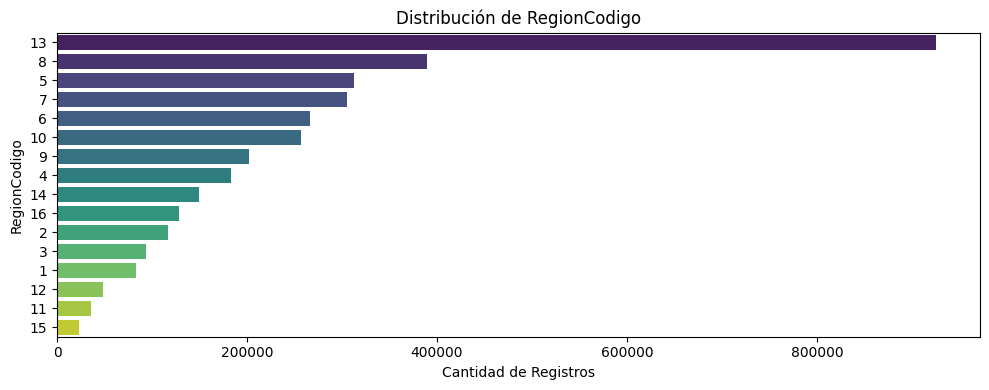

--------------------------------------------------
---- FRECUENCIAS: ComunaCodigo ----
ComunaCodigo
13110    59018
2101     54432
13401    52472
5101     49064
8301     46545
         ...  
8302      2760
5702      2616
5706      2544
5503      2484
8307      2400
Name: count, Length: 308, dtype: int64
Total de categorías únicas: 308

-> Gráfico omitido porque ComunaCodigo tiene demasiadas categorías (307).
--------------------------------------------------
---- FRECUENCIAS: ServicioSaludCodigo ----
ServicioSaludCodigo
16      304770
15      266191
10      236520
13      197323
14      190074
5       183452
7       154653
22      149248
21      138474
9       133785
17      128556
18      125675
3       116575
24      114339
6       111370
20      110034
12       97453
4        93574
19       85336
2        82935
11       76780
33       73971
23       68841
28       68594
29       63946
26       48672
8        40341
25       36052
None     24738
1        23036
Name: count, dtype: int64

C:\Users\Camilo\AppData\Local\Temp\ipykernel_9412\1773461431.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


<Figure size 1000x400 with 0 Axes>

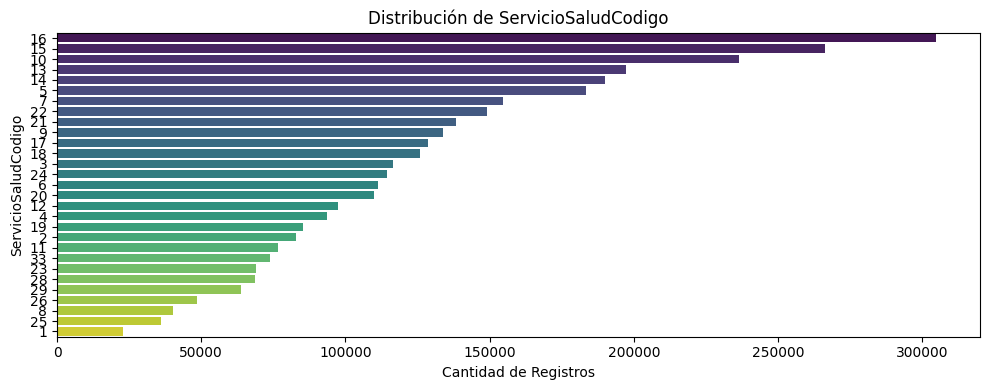

--------------------------------------------------
---- FRECUENCIAS: TipoEstablecimiento ----
TipoEstablecimiento
Servicio de Atención Primaria de Urgencia (SAPU)                         1340875
Hospital                                                                 1109073
Servicio de Urgencia Rural (SUR)                                          539454
Servicio de Atención Primaria de Urgencia de Alta Resolutividad (SAR)     506836
None                                                                       24738
Hospital                                                                   13160
Centro de Salud Familiar (CESFAM)                                           6713
Centro de Diagnóstico y Terapeútico (CDT)                                   4459
Name: count, dtype: int64
Total de categorías únicas: 8



C:\Users\Camilo\AppData\Local\Temp\ipykernel_9412\1773461431.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


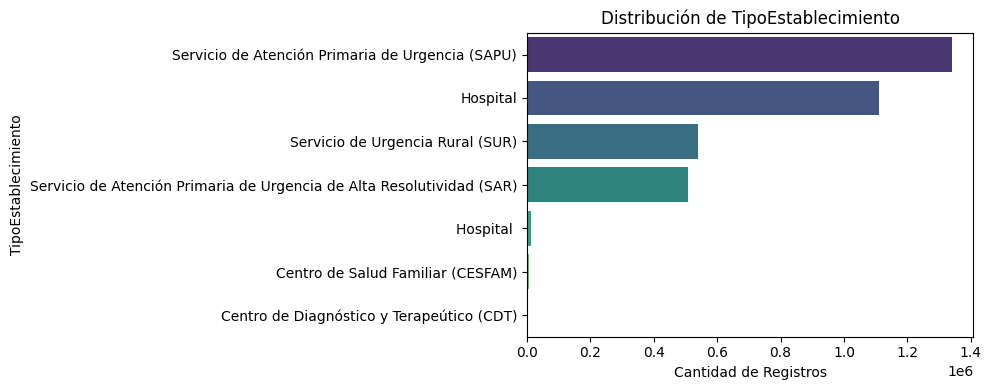

--------------------------------------------------
---- FRECUENCIAS: DependenciaAdministrativa ----
DependenciaAdministrativa
Municipal            2264573
Servicio de Salud    1200954
Municipal              27948
None                   24738
Delegados              20656
Otra Institución        6439
Name: count, dtype: int64
Total de categorías únicas: 6



C:\Users\Camilo\AppData\Local\Temp\ipykernel_9412\1773461431.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


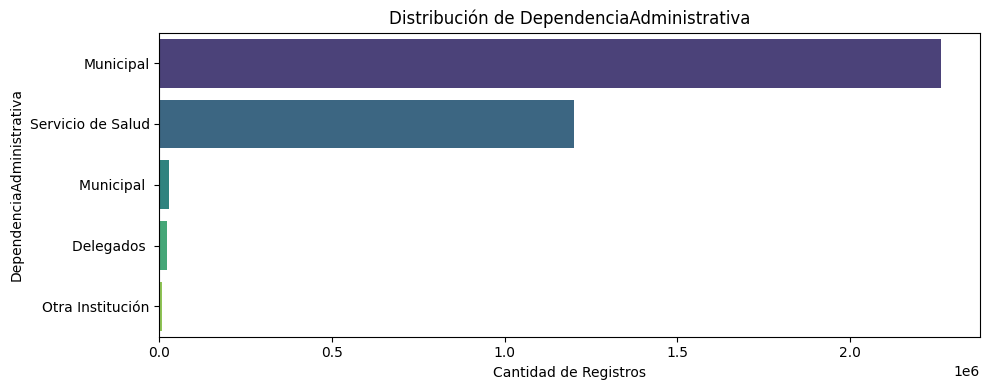

--------------------------------------------------
---- FRECUENCIAS: NivelAtencion ----
NivelAtencion
Primario      2985530
Terciario      521169
None            24738
Secundario      13871
Name: count, dtype: int64
Total de categorías únicas: 4



C:\Users\Camilo\AppData\Local\Temp\ipykernel_9412\1773461431.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


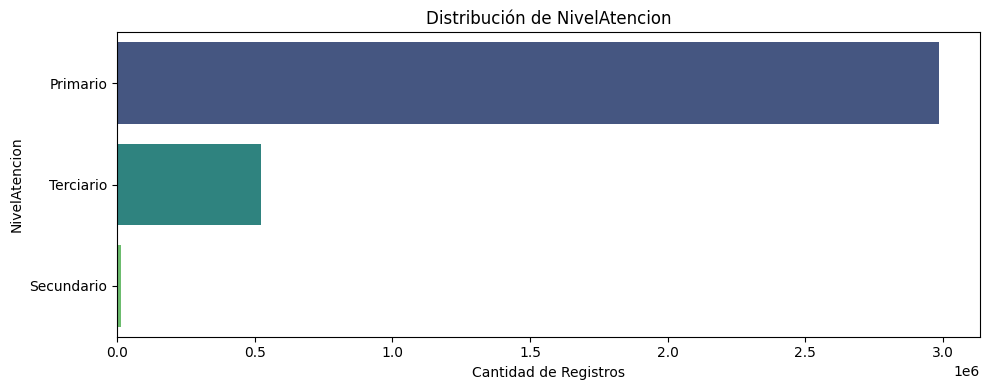

--------------------------------------------------
---- FRECUENCIAS: TipoUrgencia ----
TipoUrgencia
Urgencia Ambulatoria (SAPU)    1354090
Urgencia Hospitalaria (UEH)    1113254
Urgencia Ambulatoria (SUR)      539454
Urgencia ambulatoria (SAR)      455150
Urgencia Ambulatoria (SAR)       38471
None                             24738
Urgencia ambulatoria             10788
Urgencia Especializada            7767
Pendiente                         1212
No Aplica                          384
Name: count, dtype: int64
Total de categorías únicas: 10



C:\Users\Camilo\AppData\Local\Temp\ipykernel_9412\1773461431.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


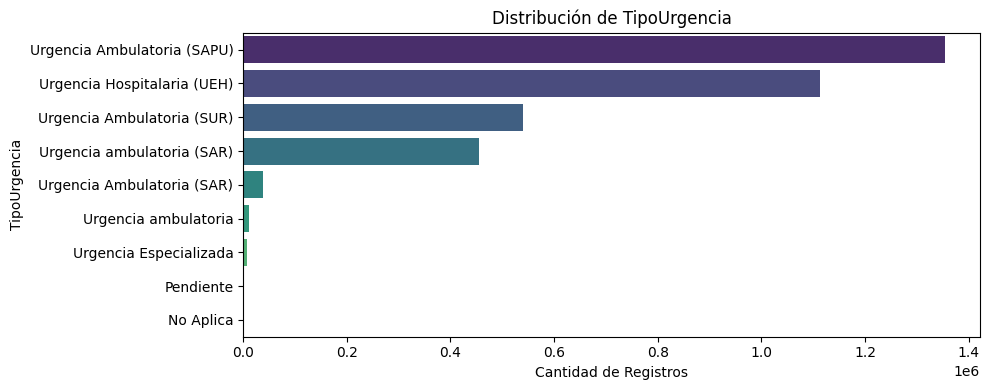

--------------------------------------------------
---- FRECUENCIAS: NivelComplejidad ----
NivelComplejidad
Baja Complejidad       2992086
Alta Complejidad        372082
Mediana Complejidad     153546
None                     24738
Completar                 2856
Name: count, dtype: int64
Total de categorías únicas: 5



C:\Users\Camilo\AppData\Local\Temp\ipykernel_9412\1773461431.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


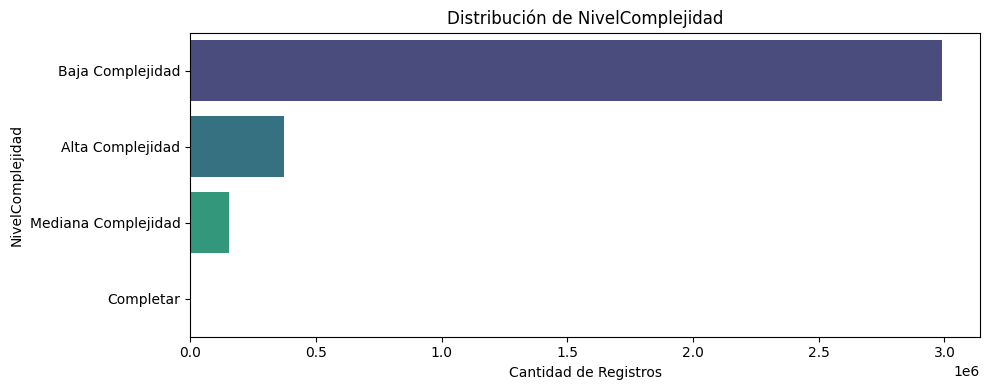

--------------------------------------------------
---- FRECUENCIAS: Causa ----
Causa
Otra causa respiratoria no contenidas en las categorías anteriores (J22; J30-J39, J47, J60-J98)    342197
IRA Alta (J00-J06)                                                                                 342197
Crisis obstructiva bronquial (J40-J46)                                                             342197
TOTAL CAUSA SISTEMA  RESPIRATORIO (J00-J98)                                                        342197
- Causas sistema respiratorio (J00-J98)                                                            342197
Bronquitis/bronquiolitis aguda (J20-J21)                                                           342197
Influenza (J09-J11)                                                                                342197
Neumonía (J12-J18)                                                                                 342197
TOTAL ATENCIONES POR COVID-19, Virus Identificado U07.1           

C:\Users\Camilo\AppData\Local\Temp\ipykernel_9412\1773461431.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


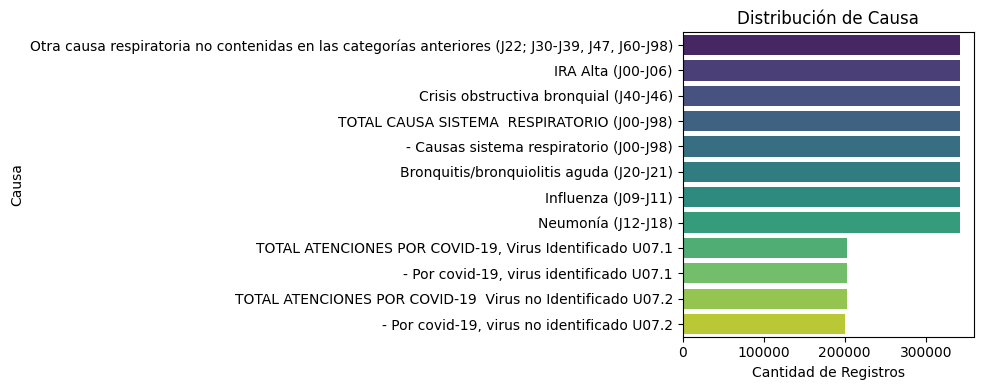

--------------------------------------------------


In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columnas que queremos revisar
#cols_a_revisar = ['ServicioSaludCodigo', 'TipoEstablecimiento', 'DependenciaAdministrativa']

# 1. Revisión de valores nulos
print("---- VALORES NULOS ----")
print(df.isnull().sum())
print("\n")

# 2. Iterar sobre las columnas para calcular frecuencias y graficarlas
for col in categoricas:
    print(f"---- FRECUENCIAS: {col} ----")
    # Ver cuántos datos hay de cada categoría
    frecuencias = df[col].value_counts(dropna=False)
    print(frecuencias)
    print(f"Total de categorías únicas: {df[col].nunique(dropna=False)}\n")
    
    # Gráficos si no son demasiadas categorías (para ServicioSaludCodigo puede que sean muchas)
    plt.figure(figsize=(10, 4))
    if df[col].nunique() < 50:
        sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')
        plt.title(f'Distribución de {col}')
        plt.xlabel('Cantidad de Registros')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()
    else:
        print(f"-> Gráfico omitido porque {col} tiene demasiadas categorías ({df[col].nunique()}).")
    print("-" * 50)





In [79]:
# Eliminar todas las filas que contengan al menos un valor nulo (NaN) en cualquier columna
filas_previo = len(df)
print(f"Filas antes de eliminar nulos: {len(df)}")
df = df.dropna()
print(f"Filas después de eliminar nulos: {len(df)}")
print(f"Se eliminaron {filas_previo - len(df)} filas en total.")

Filas antes de eliminar nulos: 3545308
Filas después de eliminar nulos: 3520570
Se eliminaron 24738 filas en total.


In [80]:
#Comprobando si quedan nulos despues de la limpieza
import duckdb as db
con = db.connect()
con.register('df', df)
query = " select * from df where EstablecimientoCodigo is null"
result = con.execute(query).fetchdf()
print(result)
result.to_csv(f'../resultados/establecimientoNulo_DespuesLimpieza_{fecha_actual}.csv', index=False)

query = " select * from df where NivelComplejidad = '1.0'"
result = con.execute(query).fetchdf()
print(result)
result.to_csv(f'../resultados/NivelComplejidad123_{fecha_actual}.csv', index=False)

Empty DataFrame
Columns: [EstablecimientoCodigo, RegionCodigo, ComunaCodigo, ServicioSaludCodigo, TipoEstablecimiento, DependenciaAdministrativa, NivelAtencion, TipoUrgencia, NivelComplejidad, Anio, SemanaEstadistica, OrdenCausa, Causa, NumTotal]
Index: []
Empty DataFrame
Columns: [EstablecimientoCodigo, RegionCodigo, ComunaCodigo, ServicioSaludCodigo, TipoEstablecimiento, DependenciaAdministrativa, NivelAtencion, TipoUrgencia, NivelComplejidad, Anio, SemanaEstadistica, OrdenCausa, Causa, NumTotal]
Index: []


## Limpieza EstablecimientoCodigo, RegionCodigo, ComunaCodigo

In [81]:
print("--- REPORTE DE DATOS INVÁLIDOS ---")
columnas_interes = ['EstablecimientoCodigo', 'RegionCodigo', 'ComunaCodigo']
for col in columnas_interes:
    # 1. Hacemos una conversión "virtual" o temporal. 
    # Lo que no sea número se vuelve nulo temporalmente, pero el 'df' original queda intacto.
    simulacion = pd.to_numeric(df[col], errors='coerce')
    
    # 2. Comparamos: Buscamos filas que originalmente NO estaban vacías, 
    # pero que fallaron en la simulación matemática.
    datos_malos = df[(df[col].notnull()) & (simulacion.isnull())]
    
    # 3. Mostramos los resultados
    cantidad_errores = len(datos_malos)
    
    if cantidad_errores > 0:
        print(f"\n⚠️ PELIGRO: La columna '{col}' tiene {cantidad_errores} datos inválidos (no son números).")
        print("Aquí tienes los primeros 5 ejemplos de los datos problemáticos para que los veas:")
        # display() es perfecto en Jupyter para mostrar tablitas bonitas
        display(datos_malos[[col]].head()) 
    else:
        print(f"\n✅ La columna '{col}' está limpia. Todos sus textos son números válidos.")

--- REPORTE DE DATOS INVÁLIDOS ---

✅ La columna 'EstablecimientoCodigo' está limpia. Todos sus textos son números válidos.

✅ La columna 'RegionCodigo' está limpia. Todos sus textos son números válidos.

✅ La columna 'ComunaCodigo' está limpia. Todos sus textos son números válidos.


--- 

## Limpieza Anio, NivelComplejidad

In [82]:
from datetime import datetime

df['NC_Original'] = df['NivelComplejidad'].astype(str)


df['NivelComplejidad'] = df['NivelComplejidad'].astype(str).str.strip().str.title()

mapeo_rescate = {
    'Baja': 'Baja Complejidad', 'Bajacomplejidad': 'Baja Complejidad',
    'Mediana': 'Mediana Complejidad', 'Medianacomplejidad': 'Mediana Complejidad',
    'Alta': 'Alta Complejidad', 'Altacomplejidad': 'Alta Complejidad',
    'N/A': 'No Aplica', 'Na': 'No Aplica', 'Noaplica': 'No Aplica'
}
df['NivelComplejidad'] = df['NivelComplejidad'].replace(mapeo_rescate)

categorias_validas = ['Alta Complejidad', 'Mediana Complejidad', 'Baja Complejidad', 'No Aplica', 'Pendiente']
df.loc[~df['NivelComplejidad'].isin(categorias_validas), 'NivelComplejidad'] = 'Pendiente'

anio_actual = datetime.now().year

df = df.dropna(subset=['Anio'])
df['Anio'] = df['Anio'].astype(int)
df = df[(df['Anio'] >= 2014) & (df['Anio'] <= anio_actual)]

mask_cambio = df['NC_Original'] != df['NivelComplejidad']
reporte_cambios = df[mask_cambio].groupby(['NC_Original', 'NivelComplejidad']).size().reset_index(name='Casos')

print(f"Registros eliminados (por año inválido): {filas_iniciales - len(df) if 'filas_iniciales' in locals() else 'revisar'}")
print("\nDetalle de correcciones en Nivel de Complejidad:")
print(reporte_cambios.sort_values('Casos', ascending=False))

df = df.drop(columns=['NC_Original'])

Registros eliminados (por año inválido): revisar

Detalle de correcciones en Nivel de Complejidad:
  NC_Original NivelComplejidad  Casos
0   Completar        Pendiente   2856


In [83]:
def limpiar_datos_urgencia(df):
    print("Limpieza de NivelAtencion y TipoUrgencia...")
    
    df_limpio = df.copy()
    
    columnas_objetivo = ['NivelAtencion', 'TipoUrgencia']
    
    print("Nulos antes de limpiar:")
    print(df_limpio[columnas_objetivo].isnull().sum())
    
    # Limpieza
    for col in columnas_objetivo:
        # Rellenar nulos
        #df_limpio[col] = df_limpio[col].fillna('DESCONOCIDO')
        
        # Pasar a mayúsculas y quitar espacios extra
        df_limpio[col] = df_limpio[col].astype(str).str.strip().str.upper()

    # Nulos finales
    print("\nNulos después de limpiar:")
    print(df_limpio[columnas_objetivo].isnull().sum())
    print("-" * 50)
    
    return df_limpio

df = limpiar_datos_urgencia(df)
df.head().to_csv(f'../resultados/limpieza_rafa_{fecha_actual}.csv', index=False)

Limpieza de NivelAtencion y TipoUrgencia...
Nulos antes de limpiar:
NivelAtencion    0
TipoUrgencia     0
dtype: int64

Nulos después de limpiar:
NivelAtencion    0
TipoUrgencia     0
dtype: int64
--------------------------------------------------


## Estandarizacion Causa

In [84]:
df['Causa_Busqueda'] = df['Causa'].str.lower().str.replace(r'^- ', '', regex=True).str.strip()

mapeo_codigos = {
    'j00-j06': 'IRA alta (J00-J06)',
    'j09-j11': 'Influenza (J09-J11)',
    'j12-j18': 'Neumonía (J12-J18)',
    'j20-j21': 'Bronquitis/Bronquiolitis aguda (J20-J21)',
    'j40-j46': 'Crisis obstructiva bronquial (J40-J46)',
    'j22': 'Otra causa respiratoria (J22, J30-J39, J47, J60-J98)',
    'u07.1': 'COVID-19, virus identificado (U07.1)',
    'u07.2': 'COVID-19, virus no identificado (U07.2)'
}

def clasificar(texto):
    if 'total' in texto:
        return 'DESCARTAR'
    for codigo, nombre_oficial in mapeo_codigos.items():
        if codigo in texto:
            return nombre_oficial
    return 'DESCARTAR'

df['Causa_Final'] = df['Causa_Busqueda'].apply(clasificar)

# 3. Quedarnos solo con los datos limpios
df = df[df['Causa_Final'] != 'DESCARTAR'].copy()

# 4. Limpieza final de columnas (quitamos la auxiliar de búsqueda y renombramos)
df = df.drop(columns=['Causa', 'Causa_Busqueda'])
df = df.rename(columns={'Causa_Final': 'Causa'})

## Analisis Atipicos de NumTotal

1. Rango de Semanas: 1 a 53
   -> Registros fuera de rango (1-53): 0
2. Rango de OrdenCausa: 4 a 35
   -> Verificación: OK

----------------------------------------



C:\Users\Camilo\AppData\Local\Temp\ipykernel_9412\2767342904.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outliers_por_causa = df.groupby('Causa').apply(detect_outliers_iqr)


3. Resumen de Límites y Cantidad de Outliers por Causa:
                                                    Limite_Sup  Cant_Outliers
Causa                                                                        
Bronquitis/Bronquiolitis aguda (J20-J21)                  74.0        19676.0
COVID-19, virus identificado (U07.1)                       0.0        10559.0
COVID-19, virus no identificado (U07.2)                    0.0         8862.0
Crisis obstructiva bronquial (J40-J46)                    21.0        25203.0
IRA alta (J00-J06)                                       357.5        10443.0
Influenza (J09-J11)                                        5.0        44871.0
Neumonía (J12-J18)                                        18.5        27358.0
Otra causa respiratoria (J22, J30-J39, J47, J60...        26.0        41907.0


C:\Users\Camilo\AppData\Local\Temp\ipykernel_9412\2767342904.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='NumTotal', y='Causa', palette='viridis')


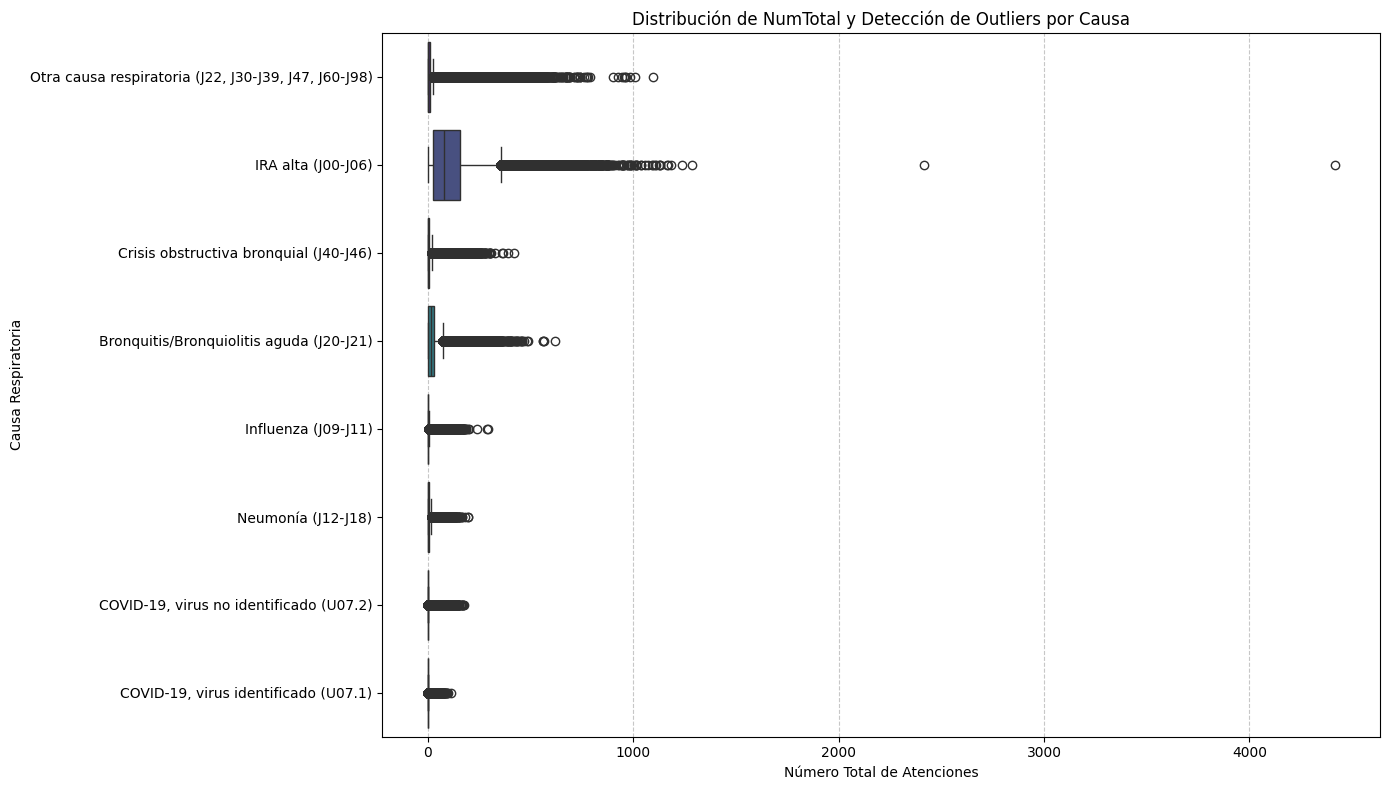


4. TOP 5 REGISTROS MÁS EXTREMOS (VALORES MÁS ALTOS):
         Anio  SemanaEstadistica               Causa  NumTotal
957999   2022                 50  IRA alta (J00-J06)      4415
3076215  2015                 43  IRA alta (J00-J06)      2415
2521315  2017                 11  IRA alta (J00-J06)      1285
3193055  2023                 20  IRA alta (J00-J06)      1236
65222    2022                  6  IRA alta (J00-J06)      1183


In [85]:
# ==================================================
# 1. VALIDACIÓN DE RANGOS LÓGICOS (NUEVO)
# ==================================================
# Chequeo de Semanas (1-53)
semanas_invalidas = df[(df['SemanaEstadistica'] < 1) | (df['SemanaEstadistica'] > 53)]
min_sem = df['SemanaEstadistica'].min()
max_sem = df['SemanaEstadistica'].max()

print(f"1. Rango de Semanas: {min_sem} a {max_sem}")
print(f"   -> Registros fuera de rango (1-53): {len(semanas_invalidas)}")

# Chequeo de OrdenCausa (3-35 según tus datos)
min_ord = df['OrdenCausa'].min()
max_ord = df['OrdenCausa'].max()
print(f"2. Rango de OrdenCausa: {min_ord} a {max_ord}")
print(f"   -> Verificación: {'OK' if min_ord >= 3 and max_ord <= 35 else 'REVISAR RANGOS'}")

print("\n" + "-"*40 + "\n")

# ==================================================
# 2. ANÁLISIS DE OUTLIERS (IQR)
# ==================================================
def detect_outliers_iqr(group):
    Q1 = group['NumTotal'].quantile(0.25)
    Q3 = group['NumTotal'].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    outliers = group[group['NumTotal'] > limite_superior]
    return pd.Series([limite_superior, len(outliers)], index=['Limite_Sup', 'Cant_Outliers'])

outliers_por_causa = df.groupby('Causa').apply(detect_outliers_iqr)

print("3. Resumen de Límites y Cantidad de Outliers por Causa:")
print(outliers_por_causa)

# ==================================================
# 3. VISUALIZACIÓN Y REGISTROS EXTREMOS
# ==================================================
# Gráfico Boxplot
plt.figure(figsize=(14, 8))
sns.boxplot(data=df, x='NumTotal', y='Causa', palette='viridis')
plt.title('Distribución de NumTotal y Detección de Outliers por Causa')
plt.xlabel('Número Total de Atenciones')
plt.ylabel('Causa Respiratoria')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n4. TOP 5 REGISTROS MÁS EXTREMOS (VALORES MÁS ALTOS):")
print(df.sort_values(by='NumTotal', ascending=False)[['Anio', 'SemanaEstadistica', 'Causa', 'NumTotal']].head())

df.head(200).to_csv(f'../resultados/LimpiezaRenatoFinalAhoraSiQueSi_{fecha_actual}.csv', index=False)

## Matrices de correlacion

### Numerica

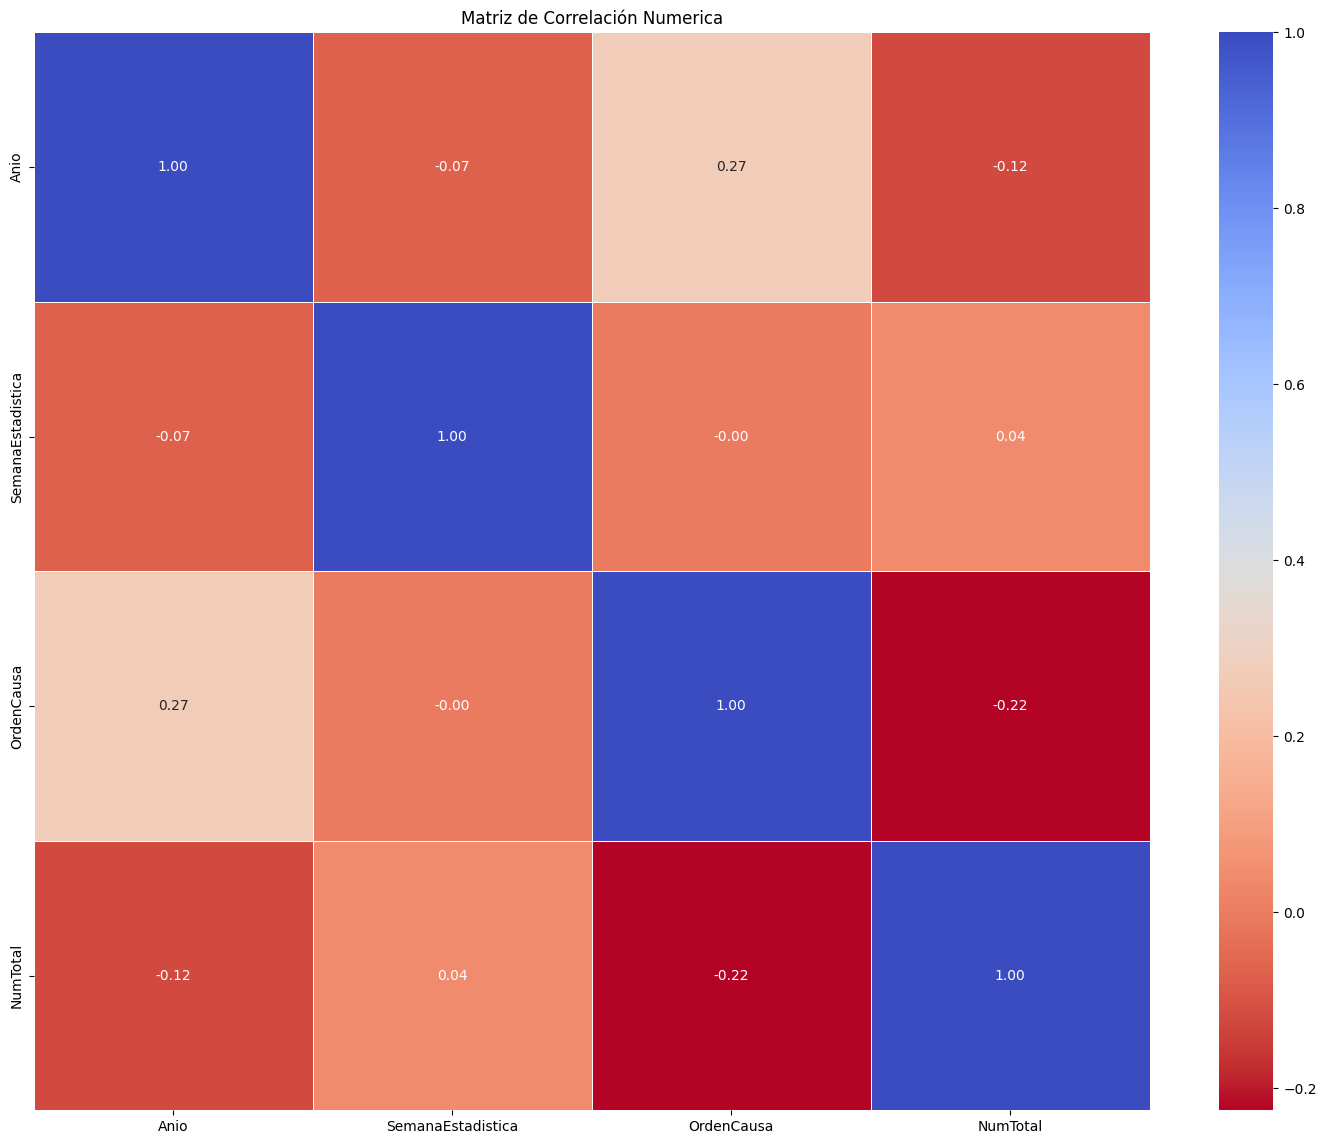

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo las columnas numéricas y booleanas (One-Hot) para la correlación
numerica_df = df.select_dtypes(include=['number', 'bool'])

# Generar la matriz de correlación (Ajustamos el tamaño para que quepan más variables)
plt.figure(figsize=(18, 14))
sns.heatmap(numerica_df.corr(), annot=True, cmap='coolwarm_r', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación Numerica')
plt.savefig(f'../resultados/matriz_correlacion_numerica_{fecha_actual}.png', dpi=300, bbox_inches='tight')  # Guardar la figura con alta resolución
plt.show()

### Categorica

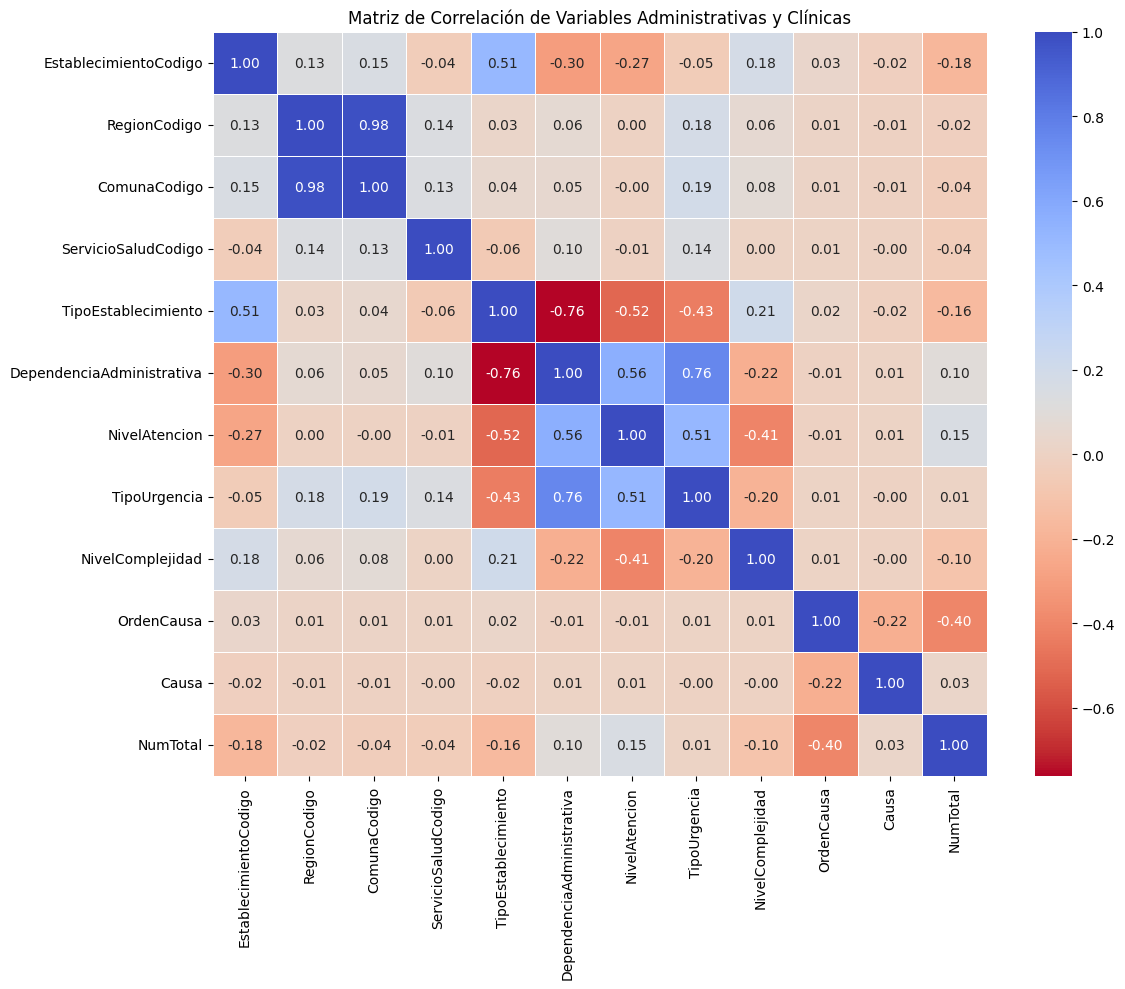

In [87]:
vars_matriz = [
    'EstablecimientoCodigo', 'RegionCodigo', 'ComunaCodigo', 
    'ServicioSaludCodigo', 'TipoEstablecimiento', 'DependenciaAdministrativa', 
    'NivelAtencion', 'TipoUrgencia', 'NivelComplejidad', 
    'OrdenCausa', 'Causa', 'NumTotal' # Agrego NumTotal para que la matriz tenga una meta
]

# 3. Preprocesamiento: Convertir categorías (strings) a números para poder correlacionar
df_corr = df[vars_matriz].copy()
for col in df_corr.select_dtypes(include=['object']).columns:
    df_corr[col] = df_corr[col].astype('category').cat.codes

# 4. Cálculo de la Matriz de Correlación (Spearman es mejor para categorías/orden)
corr_matrix = df_corr.corr(method='spearman')

# 5. Visualización con un Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm_r', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Administrativas y Clínicas')
plt.tight_layout()
plt.savefig(f'../resultados/matriz_correlacion_categorica_{fecha_actual}.png', dpi=300, bbox_inches='tight')  # Guardar la figura con alta resolución
plt.show()

# 3. Explore

### 2. Tratamiento de Variables Redundantes (Glosas vs Códigos)
Eliminamos las columnas de nombre ("Glosa") ya que contienen información redundante que aportaría colinealidad. Los códigos se forzan a tipo categórico (texto) para que no creen ponderaciones falsas en la correlación.

In [88]:
# Eliminar Glosas (nombres irrelevantes / colineales al código)
cols_glosa = ['EstablecimientoGlosa', 'RegionGlosa', 'ComunaGlosa', 'ServicioSaludGlosa']
df = df.drop(columns=cols_glosa, errors='ignore')

# Asegurar que los ID/Códigos sean texto y no números continuos
cols_codigo = ['EstablecimientoCodigo', 'RegionCodigo', 'ComunaCodigo', 'ServicioSaludCodigo']
for col_cod in cols_codigo:
    if col_cod in df.columns:
        df[col_cod] = df[col_cod].astype(str)

print("Columnas de código categorizadas correctamente. Columnas 'Glosa' eliminadas.")

Columnas de código categorizadas correctamente. Columnas 'Glosa' eliminadas.


### 3. Transformación de Variables Ordinales
Asignamos valores numéricos según su jerarquía intrínseca. 
- *NivelAtencion*: Primario (1), Secundario (2), Terciario (3)
- *NivelComplejidad*: Baja (1), Mediana (2), Alta (3)

In [89]:
# Diccionarios de mapeo para variables con jerarquía
mapa_atencion = {
    'PRIMARIO': 1,
    'SECUNDARIO': 2,
    'TERCIARIO': 3
}

mapa_complejidad = {
    'Baja Complejidad': 1,
    'Mediana Complejidad': 2,
    'Alta Complejidad': 3
}

# Aplicar los mapeos
if 'NivelAtencion' in df.columns:
    df['NivelAtencion'] = df['NivelAtencion'].map(mapa_atencion)
    
if 'NivelComplejidad' in df.columns:
    df['NivelComplejidad'] = df['NivelComplejidad'].map(mapa_complejidad)

print("Variables ordinales transformadas:")
print(df[['NivelAtencion', 'NivelComplejidad']].head(3))

Variables ordinales transformadas:
   NivelAtencion  NivelComplejidad
0              1               1.0
1              1               1.0
2              1               1.0


### 4. Transformación de Variables Nominales (One-Hot Encoding)
Para aquellas categorías que no tienen orden matemático (`TipoEstablecimiento`, `DependenciaAdministrativa`, `TipoUrgencia`, `Causa`).
Para la columna `Causa`, agruparemos las causas de menor frecuencia bajo la categoría "Otras" para evitar una explosión de columnas dispersas.

In [90]:
# Tratamiento de columna 'Causa' (agrupar causas poco comunes en 'Otras')
if 'Causa' in df.columns:
    # Determinamos el límite: nos quedaremos solo con causas que representen al menos el ~5% de los datos (o el top 5)
    frecuencias_causas = df['Causa'].value_counts(normalize=True)
    # Por ejemplo, conservamos causas que superen el 3% de los registros
    causas_importantes = frecuencias_causas[frecuencias_causas > 0.03].index
    
    # Reemplazar con 'Otras_Causas' a los que no estén en `causas_importantes`
    df['Causa'] = df['Causa'].apply(lambda x: x if x in causas_importantes else 'Otras_Causas')

# Aplicar One-Hot Encoding
columnas_nominales = ['TipoEstablecimiento', 'DependenciaAdministrativa', 'TipoUrgencia', 'Causa']
# Filtramos para asegurar que las columnas existan en el df actual antes de get_dummies
columnas_nominales_validas = [col for col in columnas_nominales if col in df.columns]

# Generamos las columnas One-Hot. Con drop_first=True evitamos mínima colinealidad extra si prefieres. 
# Dejaremos drop_first=False para fácil interpretabilidad en la correlación.
df = pd.get_dummies(df, columns=columnas_nominales_validas, drop_first=False)

print(f"Dimensiones del DataFrame después de One-Hot Encoding: {df.shape}")

Dimensiones del DataFrame después de One-Hot Encoding: (2439465, 38)


In [91]:
fecha_actual = datetime.now().strftime("%Y-%m-%d-%H%M%S")

df.head(100).to_csv(f'../resultados/DatosFormatoNumerico_{fecha_actual}.csv', index=False)

In [92]:


df.to_parquet(f'./dataset_limpios/at_urg_respiratorio_limpio_{fecha_actual}.parquet', index=False, engine='fastparquet')